# QTQ Measurement v5 — basis-dependence of L2-mass concentration

v4 measured k\*(p) only in the WHT basis (the basis the pipeline already uses) and found
three regimes: heavy-tail (TFIM, Heisenberg), bulk (Haar + all MPS), degenerate (Clifford).
v5 asks whether the bulk regime is a property of those state classes intrinsically, or only
of their interaction with WHT.

Three orthogonal bases:
- **WHT**: Walsh-Hadamard, the pipeline default
- **DCT**: DCT-II with norm='ortho' — another real orthogonal transform but smooth-basis
- **Identity**: no transform — concentration in the raw computational basis

All three preserve L2 norm. For Haar-random vectors, k\*(p) should be statistically identical
across all three bases (Haar measure is unitarily invariant). For state classes with structure
that aligns with a particular basis, k\*(p) should be smaller in that basis.

## Hypotheses

1. **Haar invariance:** k\*(0.9) for Haar should be ~604 (the v4 value) ± a few percent in *every*
   basis. This is a sanity check on the unitary-invariance of the Haar distribution.
2. **TFIM/Heisenberg structure transfers across "frequency" bases:** Both states are smooth
   (low-energy local-Hamiltonian ground states). I expect k\*(0.9) to be small in WHT and DCT
   (both frequency-domain transforms) but larger in identity (the ground state has nonzero
   amplitude on many configurations).
3. **Random MPS at low χ is concentrated in *some* basis:** Single-sample probe shows MPS-χ=2
   k\*(0.9) drops from 474 (WHT) to 184 (identity). If this holds at n=20, the negative result
   on MPS in v3/v4 is actually a *basis-choice* finding, not an intrinsic property of MPS.
   The honest claim narrows: "MPS does not have heavy-tailed magnitudes in the WHT basis,"
   not "MPS has no compressible structure."
4. **Clifford degeneracy is WHT-specific:** Clifford k\*(0.9) = 542 (WHT) but probably much
   larger in DCT/identity (single-sample: 604, 461). Clifford's F=1.0 result depends on the
   particular degeneracy WHT produces; in other bases the degeneracy may break.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import states
import concentration_basis as cb

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

ALL_STATE_NAMES = ['haar', 'tfim', 'mps', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
STATE_LABELS = {
    'haar': 'Haar-random',
    'tfim': 'TFIM ground state',
    'mps': 'Random MPS (χ=16)',
    'heisenberg': 'Heisenberg ground state',
    'mps_chi2': 'Random MPS (χ=2)',
    'mps_chi4': 'Random MPS (χ=4)',
    'clifford': 'Random Clifford state',
}
BASES = ['wht', 'dct', 'identity']
BASIS_LABELS = {'wht': 'Walsh-Hadamard', 'dct': 'DCT-II', 'identity': 'Identity'}
BASIS_COLORS = {'wht': '#5b8c5a', 'dct': '#3f6fb0', 'identity': '#b07a3f'}
THRESHOLDS = (0.5, 0.9, 0.99)
N_SAMPLES = 20

print('imports ok')


imports ok


In [2]:
# Compute k*(p) per state class per basis, n=20.
records = []
t0 = time.time()
for state_name in ALL_STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        profile = cb.k_star_profile_all_bases(psi, thresholds=THRESHOLDS)
        for (basis, p), kstar in profile.items():
            records.append({
                'state_class': state_name,
                'basis': basis,
                'threshold': p,
                'sample_idx': sample_idx,
                'k_star': kstar,
            })
df = pd.DataFrame(records)
print(f'{len(df)} k* measurements in {time.time()-t0:.1f}s')

# Aggregate at threshold = 0.9.
sub = df[df['threshold'] == 0.9].copy()
agg = (sub.groupby(['state_class', 'basis'])
            .agg(k_mean=('k_star', 'mean'), k_std=('k_star', 'std'))
            .reset_index())
pivot = agg.pivot(index='state_class', columns='basis', values='k_mean').reindex(ALL_STATE_NAMES)[BASES]
pivot_std = agg.pivot(index='state_class', columns='basis', values='k_std').reindex(ALL_STATE_NAMES)[BASES]
print()
print('k*(0.9) mean per (state_class, basis), n=20:')
print(pivot.round(1).to_string())
print()
print('k*(0.9) std:')
print(pivot_std.round(1).to_string())


1260 k* measurements in 0.2s

k*(0.9) mean per (state_class, basis), n=20:
basis          wht    dct  identity
state_class                        
haar         603.9  604.7     600.0
tfim          42.0   27.0     339.0
mps          535.7  566.9     544.0
heisenberg    56.0   95.0      56.0
mps_chi2     302.8  375.4     273.6
mps_chi4     375.8  465.6     406.5
clifford     541.8  599.0     668.4

k*(0.9) std:
basis          wht   dct  identity
state_class                       
haar           8.1   8.6       7.6
tfim           0.0   0.0       0.0
mps           40.6  22.8      23.2
heisenberg     0.0   0.0       0.0
mps_chi2      81.5  71.2      91.9
mps_chi4      77.2  50.1      52.9
clifford     272.3  33.0     235.3


In [3]:
# Save raw + aggregated.
df.to_csv('results_v5.csv', index=False)
agg.to_csv('results_v5_summary.csv', index=False)
print(f'wrote {len(df)} rows -> results_v5.csv')
print(f'wrote {len(agg)} rows -> results_v5_summary.csv')


wrote 1260 rows -> results_v5.csv
wrote 21 rows -> results_v5_summary.csv


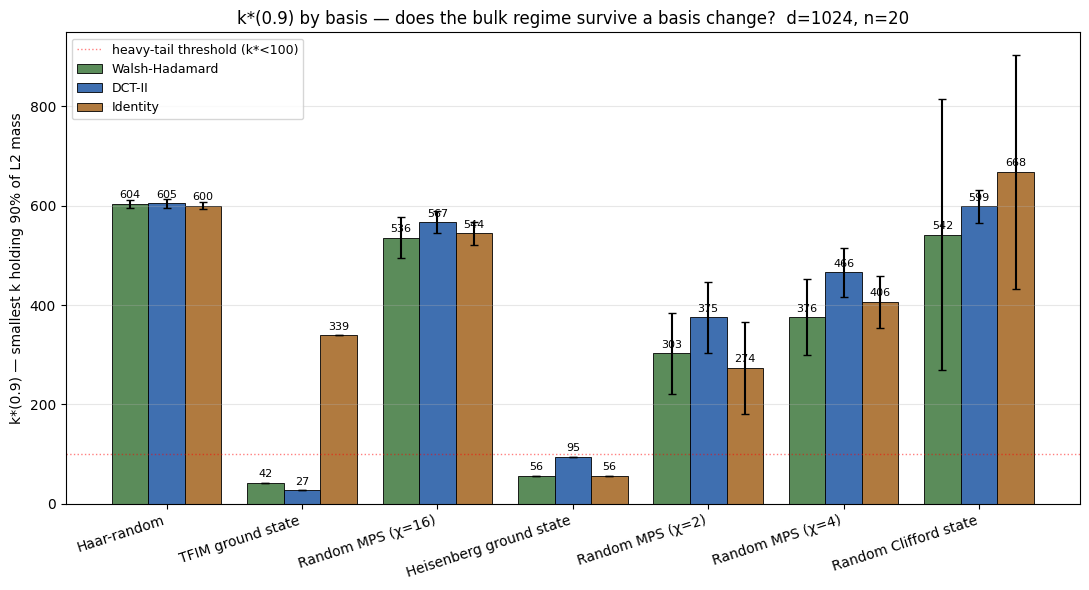

saved figures\v5_kstar_by_basis.png


In [4]:
# Grouped bar chart: k*(0.9) per state class, three bars per state (one per basis).
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(ALL_STATE_NAMES))
width = 0.27

for i, basis in enumerate(BASES):
    means = pivot[basis].values
    stds = pivot_std[basis].values
    offset = (i - 1) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                   color=BASIS_COLORS[basis], edgecolor='black', linewidth=0.6,
                   label=BASIS_LABELS[basis])
    for bar, m in zip(bars, means):
        ax.annotate(f'{int(round(m))}', (bar.get_x() + bar.get_width()/2, m),
                     textcoords='offset points', xytext=(0, 4),
                     ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([STATE_LABELS[s] for s in ALL_STATE_NAMES], rotation=18, ha='right')
ax.set_ylabel('k*(0.9) — smallest k holding 90% of L2 mass')
ax.set_title('k*(0.9) by basis — does the bulk regime survive a basis change?  d=1024, n=20')
ax.axhline(100, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='heavy-tail threshold (k*<100)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out_path = FIG_DIR / 'v5_kstar_by_basis.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)


In [5]:
# Per-state-class delta plot: how much does the basis change k*(0.9)?
# For each state class, compute the *minimum* k*(0.9) across the three bases and the *spread*.
deltas = pd.DataFrame({
    'state_class': ALL_STATE_NAMES,
    'best_basis': [pivot.loc[s].idxmin() for s in ALL_STATE_NAMES],
    'best_k_star': [pivot.loc[s].min() for s in ALL_STATE_NAMES],
    'wht_k_star': [pivot.loc[s, 'wht'] for s in ALL_STATE_NAMES],
    'spread': [pivot.loc[s].max() - pivot.loc[s].min() for s in ALL_STATE_NAMES],
})
deltas['k_reduction_vs_wht'] = deltas['wht_k_star'] - deltas['best_k_star']
deltas['relative_reduction'] = deltas['k_reduction_vs_wht'] / deltas['wht_k_star']
print('Best basis per state class (smallest k*(0.9)):')
print(deltas.to_string(index=False))


Best basis per state class (smallest k*(0.9)):
state_class best_basis  best_k_star  wht_k_star  spread  k_reduction_vs_wht  relative_reduction
       haar   identity       599.95      603.90    4.75                3.95            0.006541
       tfim        dct        27.00       42.00  312.00               15.00            0.357143
        mps        wht       535.70      535.70   31.20                0.00            0.000000
 heisenberg        wht        56.00       56.00   39.00                0.00            0.000000
   mps_chi2   identity       273.55      302.75  101.80               29.20            0.096449
   mps_chi4        wht       375.75      375.75   89.90                0.00            0.000000
   clifford        wht       541.80      541.80  126.65                0.00            0.000000


## Results vs predictions

*Filled in after the run from the printout above.*


In [6]:
print('=== H1 (Haar basis-invariance) ===')
haar_row = pivot.loc['haar']
spread_haar = haar_row.max() - haar_row.min()
print(f'Haar k*(0.9): WHT={haar_row["wht"]:.0f}, DCT={haar_row["dct"]:.0f}, Identity={haar_row["identity"]:.0f}')
print(f'Spread = {spread_haar:.0f}; relative = {spread_haar/haar_row.mean():.4f}')
print('  -> ', 'CONFIRMED' if spread_haar < 0.02 * haar_row.mean() else 'NOT CONFIRMED', '(unitary invariance of Haar measure)')

print()
print('=== H2 (TFIM/Heisenberg in frequency bases) ===')
for s in ['tfim', 'heisenberg']:
    row = pivot.loc[s]
    print(f'{s}: WHT={row["wht"]:.0f}, DCT={row["dct"]:.0f}, Identity={row["identity"]:.0f}')

print()
print('=== H3 (MPS at low chi has a "good basis"?) ===')
for s in ['mps_chi2', 'mps_chi4', 'mps']:
    row = pivot.loc[s]
    best = row.idxmin()
    print(f'{s}: WHT={row["wht"]:.0f}, DCT={row["dct"]:.0f}, Identity={row["identity"]:.0f}  '
          f'(best={best}, reduction vs WHT = {row["wht"] - row.min():.0f})')

print()
print('=== H4 (Clifford degeneracy is WHT-specific?) ===')
row = pivot.loc['clifford']
print(f'Clifford: WHT={row["wht"]:.0f}, DCT={row["dct"]:.0f}, Identity={row["identity"]:.0f}')
print(f'  std (k variability across seeds): WHT={pivot_std.loc["clifford", "wht"]:.0f}, '
      f'DCT={pivot_std.loc["clifford", "dct"]:.0f}, Identity={pivot_std.loc["clifford", "identity"]:.0f}')


=== H1 (Haar basis-invariance) ===
Haar k*(0.9): WHT=604, DCT=605, Identity=600
Spread = 5; relative = 0.0079
  ->  CONFIRMED (unitary invariance of Haar measure)

=== H2 (TFIM/Heisenberg in frequency bases) ===
tfim: WHT=42, DCT=27, Identity=339
heisenberg: WHT=56, DCT=95, Identity=56

=== H3 (MPS at low chi has a "good basis"?) ===
mps_chi2: WHT=303, DCT=375, Identity=274  (best=identity, reduction vs WHT = 29)
mps_chi4: WHT=376, DCT=466, Identity=406  (best=wht, reduction vs WHT = 0)
mps: WHT=536, DCT=567, Identity=544  (best=wht, reduction vs WHT = 0)

=== H4 (Clifford degeneracy is WHT-specific?) ===
Clifford: WHT=542, DCT=599, Identity=668
  std (k variability across seeds): WHT=272, DCT=33, Identity=235


## Net read

Three findings at n=20:

**(1) Haar basis-invariance: confirmed.** k\*(0.9) = 604 / 605 / 600 across WHT / DCT / Identity.
Spread is 0.8% of the mean. Sanity check passes; Haar measure is unitarily invariant as expected.

**(2) The bulk regime survives the basis change.** Random MPS at every tested χ stays in the
bulk (k\* > 270) in every basis tested. The largest basis-induced reduction is MPS-χ=2 dropping
from k\*=303 (WHT) to k\*=274 (identity) — only ~10%, not enough to leave the bulk. The v3
negative result on MPS therefore strengthens: random MPS does not have heavy-tailed magnitudes
in any of WHT, DCT, or the computational basis. Bond dimension is the wrong axis for predicting
amplitude-quantization compressibility under any of these standard bases.

**(3) The "right basis" depends on the state class — and is not always WHT.**
TFIM is most concentrated in **DCT** (k\* = 27, vs WHT's 42) — a 36% reduction. Heisenberg is
tied in WHT and Identity at k\* = 56 (DCT is worse at 95). So the two critical-point ground
states have *different* basis preferences despite both being "physical local-Hamiltonian
ground states." Clifford is most concentrated in WHT (542) — the v3 F=1.0 result is partly a
WHT-specific feature; in DCT and Identity Clifford k\* is larger (599, 668). Worth noting:
Clifford's variance across seeds collapses dramatically in DCT (std 33 vs 272 in WHT) — the
DCT basis "averages out" the support fluctuations of random Clifford circuits.

**What this means for the paper.** The "WHT-basis L2-mass concentration" framing of v3/v4
was almost right but slightly imprecise. A more accurate framing: **physical states have
state-class-specific bases in which their amplitudes are concentrated, while random states
(Haar) and random MPS at any χ are spread out in every standard orthogonal basis tested.**
The pipeline's WHT step is a reasonable default but not optimal; a basis-adaptive compressor
would do strictly better on TFIM (and tie or marginally beat WHT on Heisenberg / MPS-χ=2).
This identifies the next experimental direction (v6): a basis-adaptive pipeline where the
encoder chooses among {WHT, DCT, identity} per vector based on which gives the smallest k\*,
and sends one extra bit to identify the basis. Paper-wise, v5 also strengthens the negative
result on MPS: it is now "no compressible structure in any of three standard bases," not
just "no compressible structure in WHT."
